## Терешенков Александр БВТ2203. Лабораторная работа №3 RNN/LSTM/GRU

Написать LSTM для классификации текста на токсичность, используя токенизатор с HF, вывести метрики accuracy, f1, roc-auc, pr-auc.

In [ ]:
!pip install transformers

In [11]:
from transformers import AutoTokenizer, AutoModel
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.nn
import torch.optim
from torch.utils.data import Dataset, DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_recall_curve, auc, average_precision_score
from tqdm import tqdm

In [2]:
tokenizer = AutoTokenizer.from_pretrained("ai-forever/ruBert-base")
tokenizer.vocab_size

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

120138

In [12]:
data = pd.read_csv("labeled.csv")
print(data.isna().sum())
text = data["comment"]
labels = data.drop("comment", axis=1)
print(text.info(), labels.info())

comment    0
toxic      0
dtype: int64
<class 'pandas.core.series.Series'>
RangeIndex: 14412 entries, 0 to 14411
Series name: comment
Non-Null Count  Dtype 
--------------  ----- 
14412 non-null  object
dtypes: object(1)
memory usage: 112.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14412 entries, 0 to 14411
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   toxic   14412 non-null  float64
dtypes: float64(1)
memory usage: 112.7 KB
None None


In [5]:
train_data, test_data, train_label, test_label = train_test_split(text, labels, test_size=0.2)
train_data, val_data, train_label, val_label = train_test_split(train_data, train_label, test_size=0.3)

In [6]:
class CommentsDataset(Dataset):
  def __init__(self, text, labels):
    self.text = text
    self.labels = labels

  def __len__(self):
    return len(self.text)

  def __getitem__(self, idx):
    token_list = tokenizer(self.text.iloc[idx], padding="max_length", truncation=True, return_tensors="pt", max_length=128)
    return token_list["input_ids"].squeeze(0), torch.tensor(self.labels.iloc[idx])

In [7]:
batch = 64

train_dataset = CommentsDataset(train_data, train_label)
val_dataset = CommentsDataset(val_data, val_label)
test_dataset = CommentsDataset(test_data, test_label)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [8]:
class RNNClassification(torch.nn.Module):
  def __init__(self, voc_size, emb_output_size, hidden_size, num_layers):
    super().__init__()
    self.embedding = torch.nn.Embedding(voc_size, emb_output_size)
    self.rnn = torch.nn.LSTM(emb_output_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
    self.fc = torch.nn.Linear(hidden_size * 2, 1)
  def forward(self, input):
    x = self.embedding(input)
    x, _ = self.rnn(x)
    x = self.fc(x[:,-1,:])
    return x

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = RNNClassification(tokenizer.vocab_size, 128, 128, 2).to(device)
device

'cuda'

In [10]:
loss = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [13]:
epochs = 30

train_loss = []
train_accuracy = []
train_f1 = []
train_roc_auc = []
train_pr_auc = []

val_loss = []
val_accuracy = []
val_f1 = []
val_roc_auc = []
val_pr_auc = []

for epoch in range(epochs):
  model.train()
  mean_loss = 0

  pred_values = np.array([])
  true_values = np.array([])

  for batch_obj in (pbar := tqdm(train_loader)):
    t_data, t_label = batch_obj
    t_data = t_data.to(device)
    t_label = t_label.to(device)

    optimizer.zero_grad()
    output = model(t_data)
    loss_val = loss(output, t_label)
    loss_val.backward()
    optimizer.step()

    #metrics
    mean_loss += loss_val.item()
    pred_values = np.append(pred_values, output.cpu().detach().numpy())
    true_values = np.append(true_values, t_label.cpu().detach().numpy())

  len_loader = len(train_loader)
  train_loss.append(mean_loss / len_loader)
  train_accuracy.append(accuracy_score(true_values, pred_values > 0.5))
  train_f1.append(f1_score(true_values, pred_values > 0.5))
  train_roc_auc.append(roc_auc_score(true_values, pred_values))
  #precision, recall, thresholds  = precision_recall_curve(true_values, pred_values)
  train_pr_auc.append(average_precision_score(true_values, pred_values))
  model.eval()
  pred_values = np.array([])
  true_values = np.array([])
  mean_val_loss = 0
  for batch_obj in (pbar := tqdm(val_loader)):
    t_data, t_label = batch_obj
    t_data = t_data.to(device)
    t_label = t_label.to(device)
    with torch.no_grad():
      output = model(t_data)
      loss_val = loss(output, t_label)
      mean_val_loss += loss_val.item()
      pred_values = np.append(pred_values, output.cpu().detach().numpy())
      true_values = np.append(true_values, t_label.cpu().detach().numpy())
  len_loader = len(val_loader)
  val_loss.append(mean_val_loss / len_loader)
  val_accuracy.append(accuracy_score(true_values, pred_values > 0.5))
  val_f1.append(f1_score(true_values, pred_values > 0.5))
  val_roc_auc.append(roc_auc_score(true_values, pred_values))
  val_pr_auc.append(average_precision_score(true_values, pred_values))


  0%|          | 0/127 [00:00<?, ?it/s]<ipython-input-6-f2b8a3df3395>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return token_list["input_ids"].squeeze(0), torch.tensor(self.labels.iloc[idx])
  0%|          | 0/55 [00:00<?, ?it/s]<ipython-input-6-f2b8a3df3395>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return token_list["input_ids"].squeeze(0), torch.tensor(self.labels.iloc[idx])
  0%|          | 0/127 [00:00<?, ?it/s]<ipython-input-6-f2b8a3df3395>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consisten

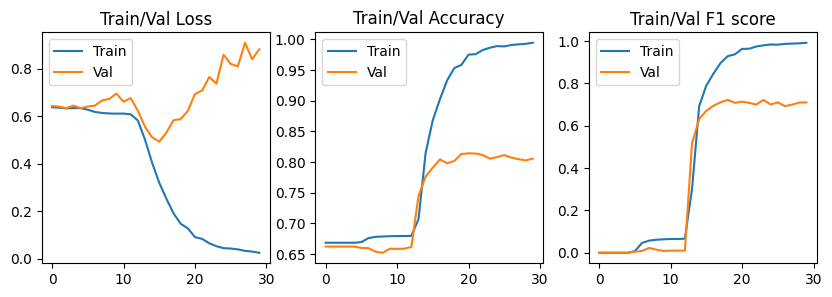

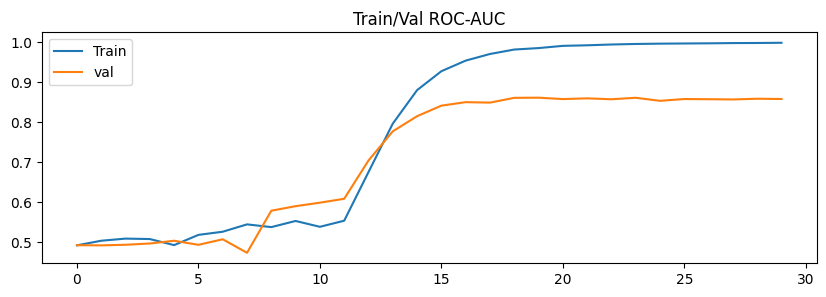

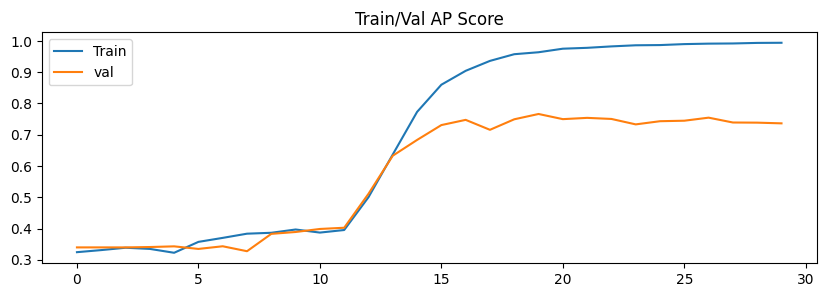

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].plot(range(len(train_loss)), train_loss, label="Train")
ax[0].plot(range(len(val_loss)), val_loss, label="Val")
ax[0].set_title("Train/Val Loss")
ax[0].legend()
ax[1].plot(range(len(train_accuracy)), train_accuracy, label="Train")
ax[1].plot(range(len(val_accuracy)), val_accuracy, label="Val")
ax[1].set_title("Train/Val Accuracy")
ax[1].legend()
ax[2].plot(range(len(train_f1)), train_f1, label="Train")
ax[2].plot(range(len(val_f1)), val_f1, label="Val")
ax[2].set_title("Train/Val F1 score")
ax[2].legend()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(range(len(train_roc_auc)), train_roc_auc, label="Train")
ax.plot(range(len(val_roc_auc)), val_roc_auc, label="val")
ax.set_title("Train/Val ROC-AUC")
ax.legend()
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(range(len(train_pr_auc)), train_pr_auc, label="Train")
ax.plot(range(len(val_pr_auc)), val_pr_auc, label="val")
ax.set_title("Train/Val AP Score")
ax.legend()
plt.show()


In [17]:
loss = torch.nn.BCEWithLogitsLoss()

In [20]:
model.eval()
pred_values = np.array([])
true_values = np.array([])
for batch_obj in test_loader:
    t_data, t_label = batch_obj
    t_data = t_data.to(device)
    t_label = t_label.to(device)
    with torch.no_grad():
      output = model(t_data)
      pred_values = np.append(pred_values, output.cpu().detach().numpy())
      true_values = np.append(true_values, t_label.cpu().detach().numpy())
len_loader = len(val_loader)
accuracy_test = accuracy_score(true_values, pred_values > 0.5)
f1_test = f1_score(true_values, pred_values > 0.5)
print(f"Accuracy = {accuracy_test}, F1 Score = {f1_test}")

<ipython-input-6-f2b8a3df3395>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return token_list["input_ids"].squeeze(0), torch.tensor(self.labels.iloc[idx])


Accuracy = 0.7995143947277142, F1 Score = 0.7011375387797312
